In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("pastel")

import warnings
warnings.filterwarnings("ignore")


In [2]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

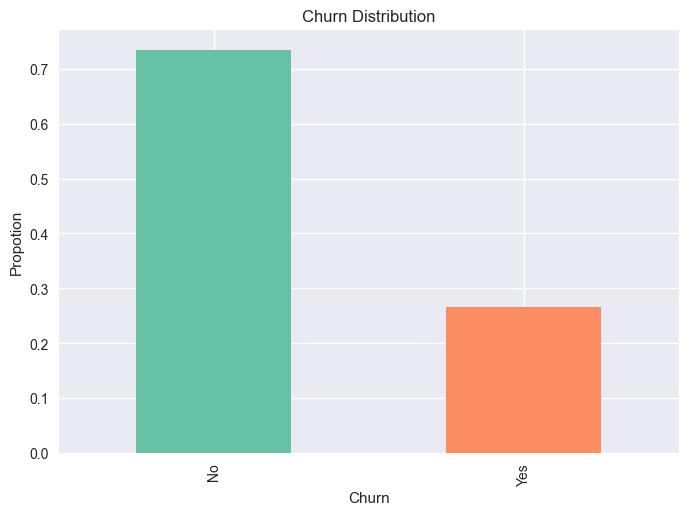

--------------------
 Churn Rate: 26.54%
--------------------


In [6]:
df["Churn"].value_counts(normalize=True).plot(
    kind = 'bar',
    color=['#66c2a5', '#fc8d62']
)

plt.title("Churn Distribution")
plt.ylabel("Propotion")
plt.xlabel("Churn")
plt.show()

churn_rate = (df["Churn"] == "Yes").mean()
print(f"--------------------\n Churn Rate: {churn_rate:.2%}\n--------------------")

In [7]:
df.drop("customerID", axis=1, inplace=True)

## Numeric Features

In [10]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Null check after transformation
df["TotalCharges"].isnull().sum()

11

In [11]:
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
print(f"Numeric Features: {numeric_features}")

Numeric Features: ['tenure', 'MonthlyCharges', 'TotalCharges']


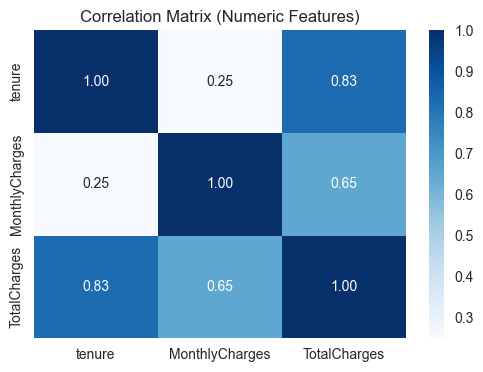

In [22]:
corr = df[["tenure", "MonthlyCharges", "TotalCharges"]].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Matrix (Numeric Features)")
plt.show()

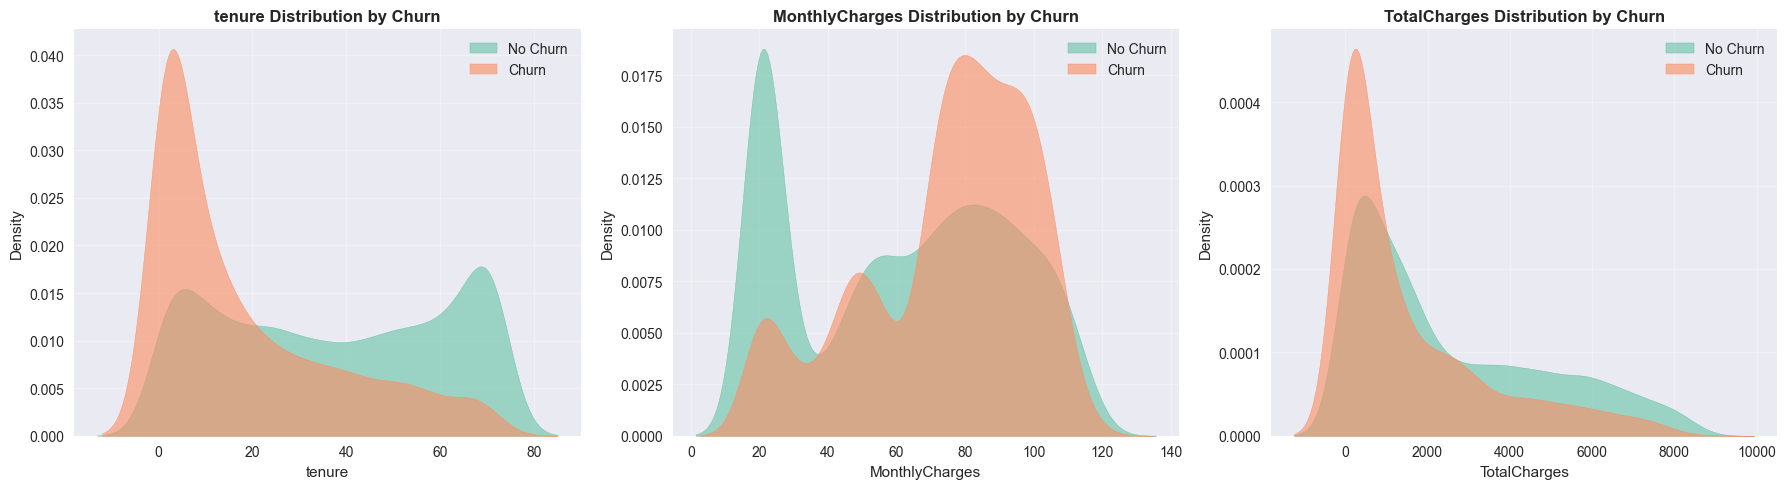

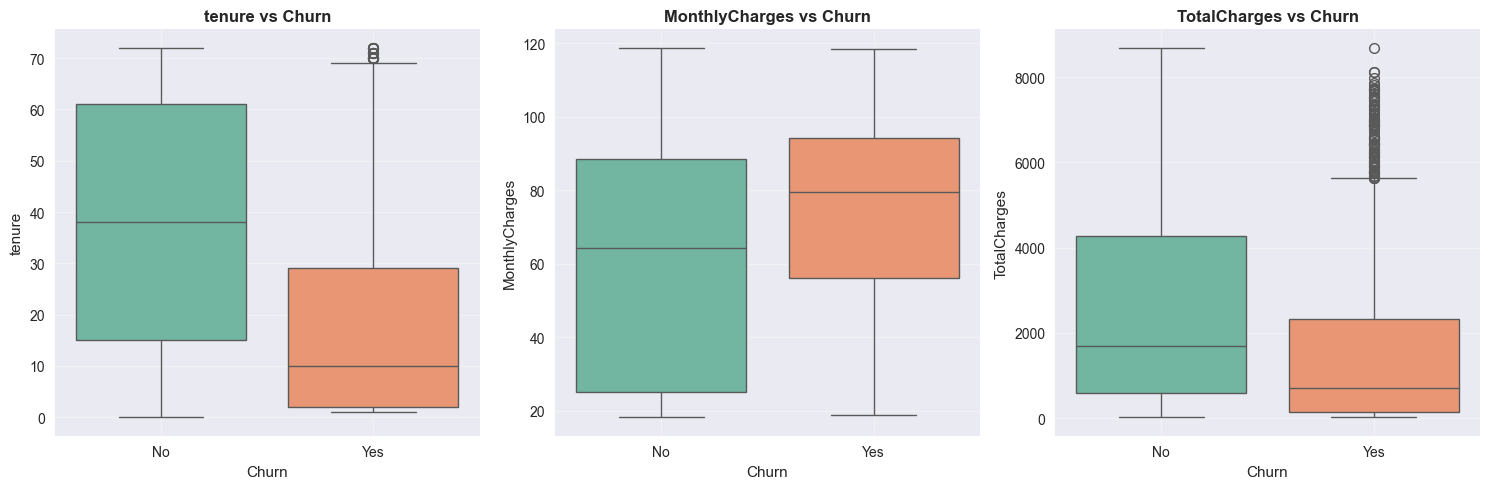


Statistical Summary by Churn Status:

tenure:
        mean  median    std  min  max
Churn                                
No     37.57    38.0  24.11    0   72
Yes    17.98    10.0  19.53    1   72
------------------------------------------------------------

MonthlyCharges:
        mean  median    std    min     max
Churn                                     
No     61.27   64.43  31.09  18.25  118.75
Yes    74.44   79.65  24.67  18.85  118.35
------------------------------------------------------------

TotalCharges:
          mean   median      std    min      max
Churn                                           
No     2555.34  1683.60  2329.46  18.80  8672.45
Yes    1531.80   703.55  1890.82  18.85  8684.80
------------------------------------------------------------


In [12]:
# Detailed visualization and statistics for numeric features

# 1. Distribution Plots (histogram + KDE)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feature in enumerate(numeric_features):
    sns.kdeplot(data=df[df["Churn"] == "No"], x=feature, 
                label="No Churn", color='#66c2a5', ax=axes[i], fill=True, alpha=0.6)
    sns.kdeplot(data=df[df["Churn"] == "Yes"], x=feature, 
                label="Churn", color='#fc8d62', ax=axes[i], fill=True, alpha=0.6)
    axes[i].set_title(f"{feature} Distribution by Churn", fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Density")
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Box Plots
plt.figure(figsize=(15, 5))
for i, feature in enumerate(numeric_features, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(data=df, x="Churn", y=feature, palette="Set2")
    plt.title(f"{feature} vs Churn", fontsize=12, fontweight='bold')
    plt.xlabel("Churn")
    plt.ylabel(feature)
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Statistical Summary
print("\n" + "="*60)
print("Statistical Summary by Churn Status:")
print("="*60)
for feature in numeric_features:
    print(f"\n{feature}:")
    summary = df.groupby("Churn")[feature].agg(['mean', 'median', 'std', 'min', 'max'])
    print(summary.round(2))
    print("-" * 60)

**Insights (Numerical Features):**  
- Customers with shorter tenure and high monthly charges tend to churn more.  
- Long-term customers show a much lower probability of churn.

## Binary Features

In [15]:
binary_features = []
for col in df.columns:
    if col == "Churn":
        continue
    if df[col].nunique() == 2:
        binary_features.append(col)

print(f"Binary features: {binary_features}")

Binary features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']


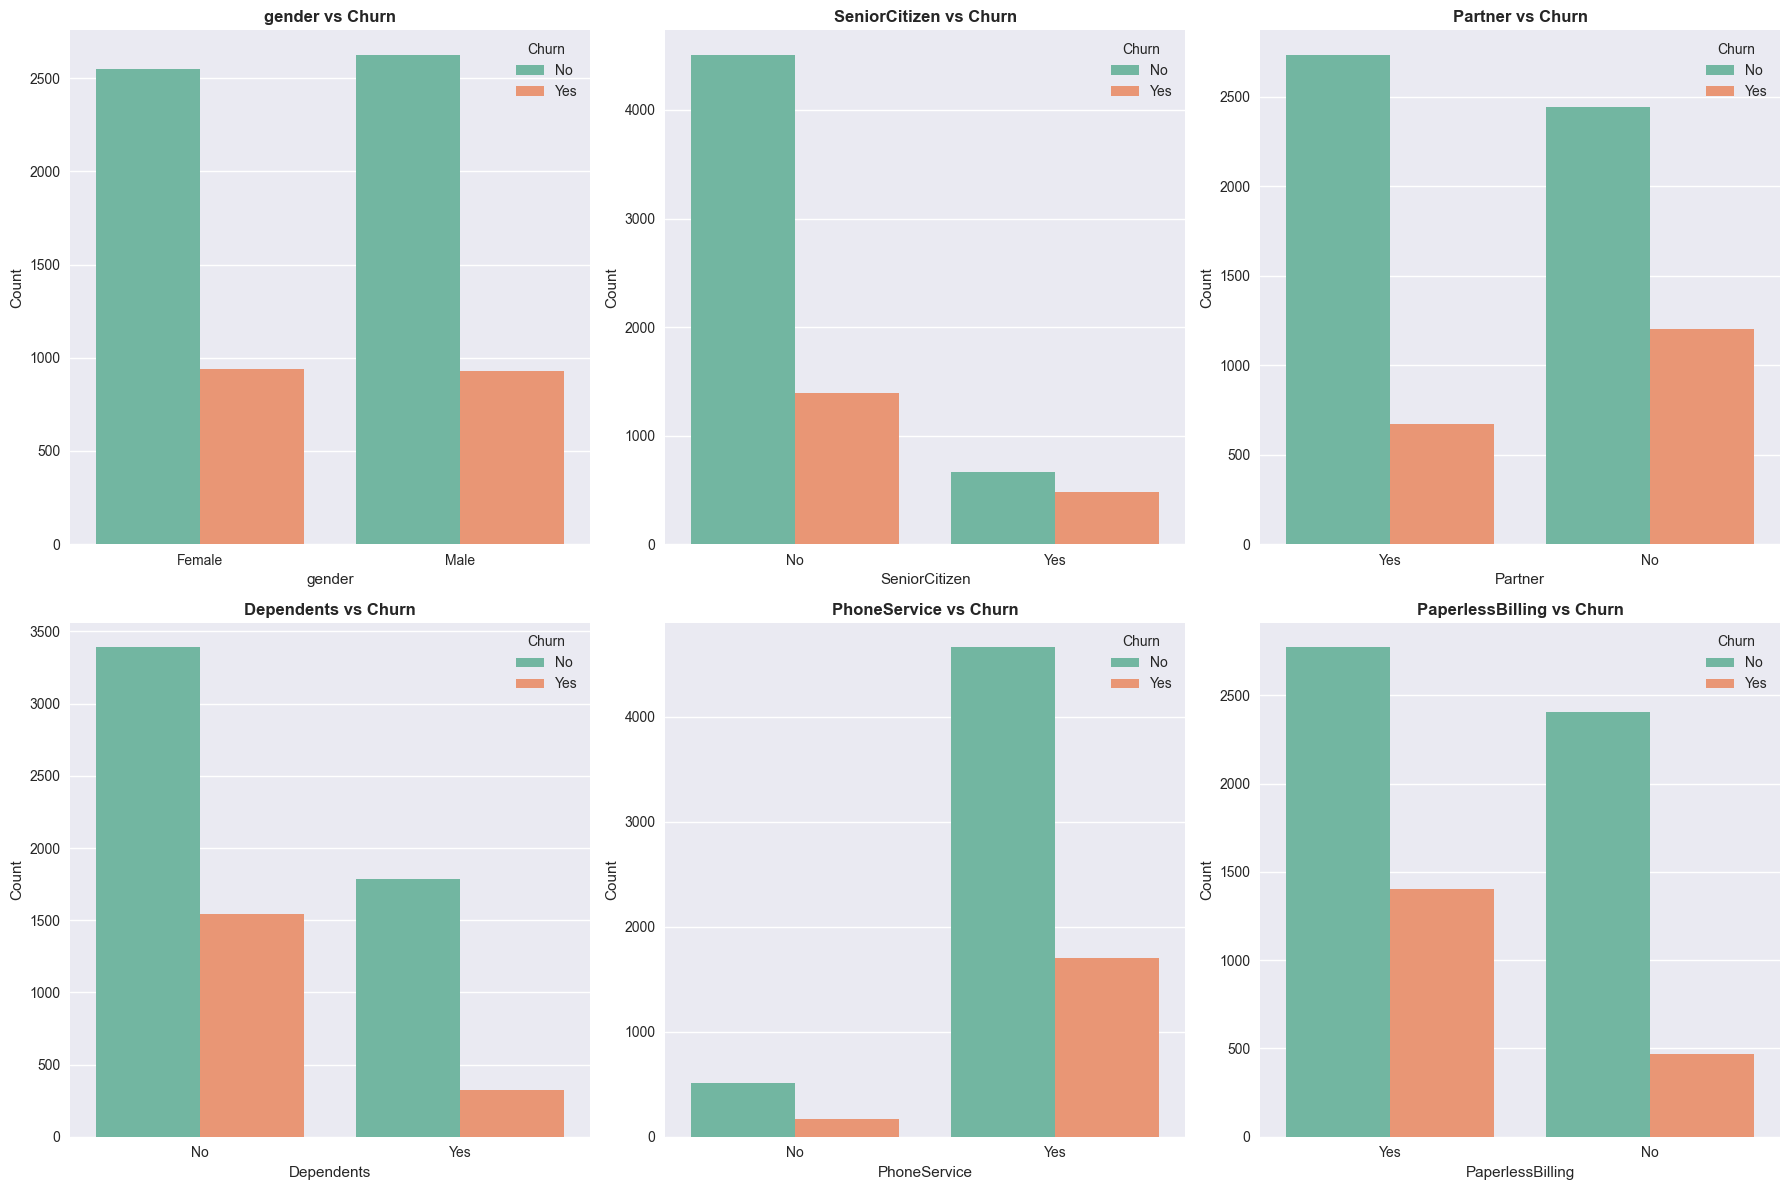


Churn Rate by Binary Features:

gender:
gender
Female    0.269209
Male      0.261603
Name: Churn, dtype: float64

SeniorCitizen:
SeniorCitizen
0    0.236062
1    0.416813
Name: Churn, dtype: float64

Partner:
Partner
No     0.329580
Yes    0.196649
Name: Churn, dtype: float64

Dependents:
Dependents
No     0.312791
Yes    0.154502
Name: Churn, dtype: float64

PhoneService:
PhoneService
No     0.249267
Yes    0.267096
Name: Churn, dtype: float64

PaperlessBilling:
PaperlessBilling
No     0.163301
Yes    0.335651
Name: Churn, dtype: float64


In [16]:
# Visualization for Binary Features
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, col in enumerate(binary_features):
    if col == 'SeniorCitizen':
        # SeniorCitizen için özel işleme
        sns.countplot(data=df, x=col, hue="Churn", palette="Set2", ax=axes[i])
        axes[i].set_xticks([0, 1])
        axes[i].set_xticklabels(["No", "Yes"])
    else:
        sns.countplot(data=df, x=col, hue="Churn", palette="Set2", ax=axes[i])
    
    axes[i].set_title(f"{col} vs Churn", fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].legend(title="Churn", labels=["No", "Yes"])

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("Churn Rate by Binary Features:")
print("="*50)
for col in binary_features:
    churn_rate = df.groupby(col)["Churn"].apply(lambda x: (x == "Yes").mean())
    print(f"\n{col}:")
    print(churn_rate)

**Insights (Binary Features):**  
- Gender has minimal impact on churn.  
- Senior citizens churn at a higher rate, but younger customers make up most of the total churn volume.  
- Customers without partners or dependents are more likely to leave.  
- Paperless billing users churn more, possibly younger and less loyal customers.

## Categorical Features

In [17]:
categorical_features = [col for col in df.columns
                        if col not in binary_features
                        and col != "Churn"
                        and df[col].dtype == "object"
                       ]

print(f"Categorical Features : {categorical_features}")

Categorical Features : ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


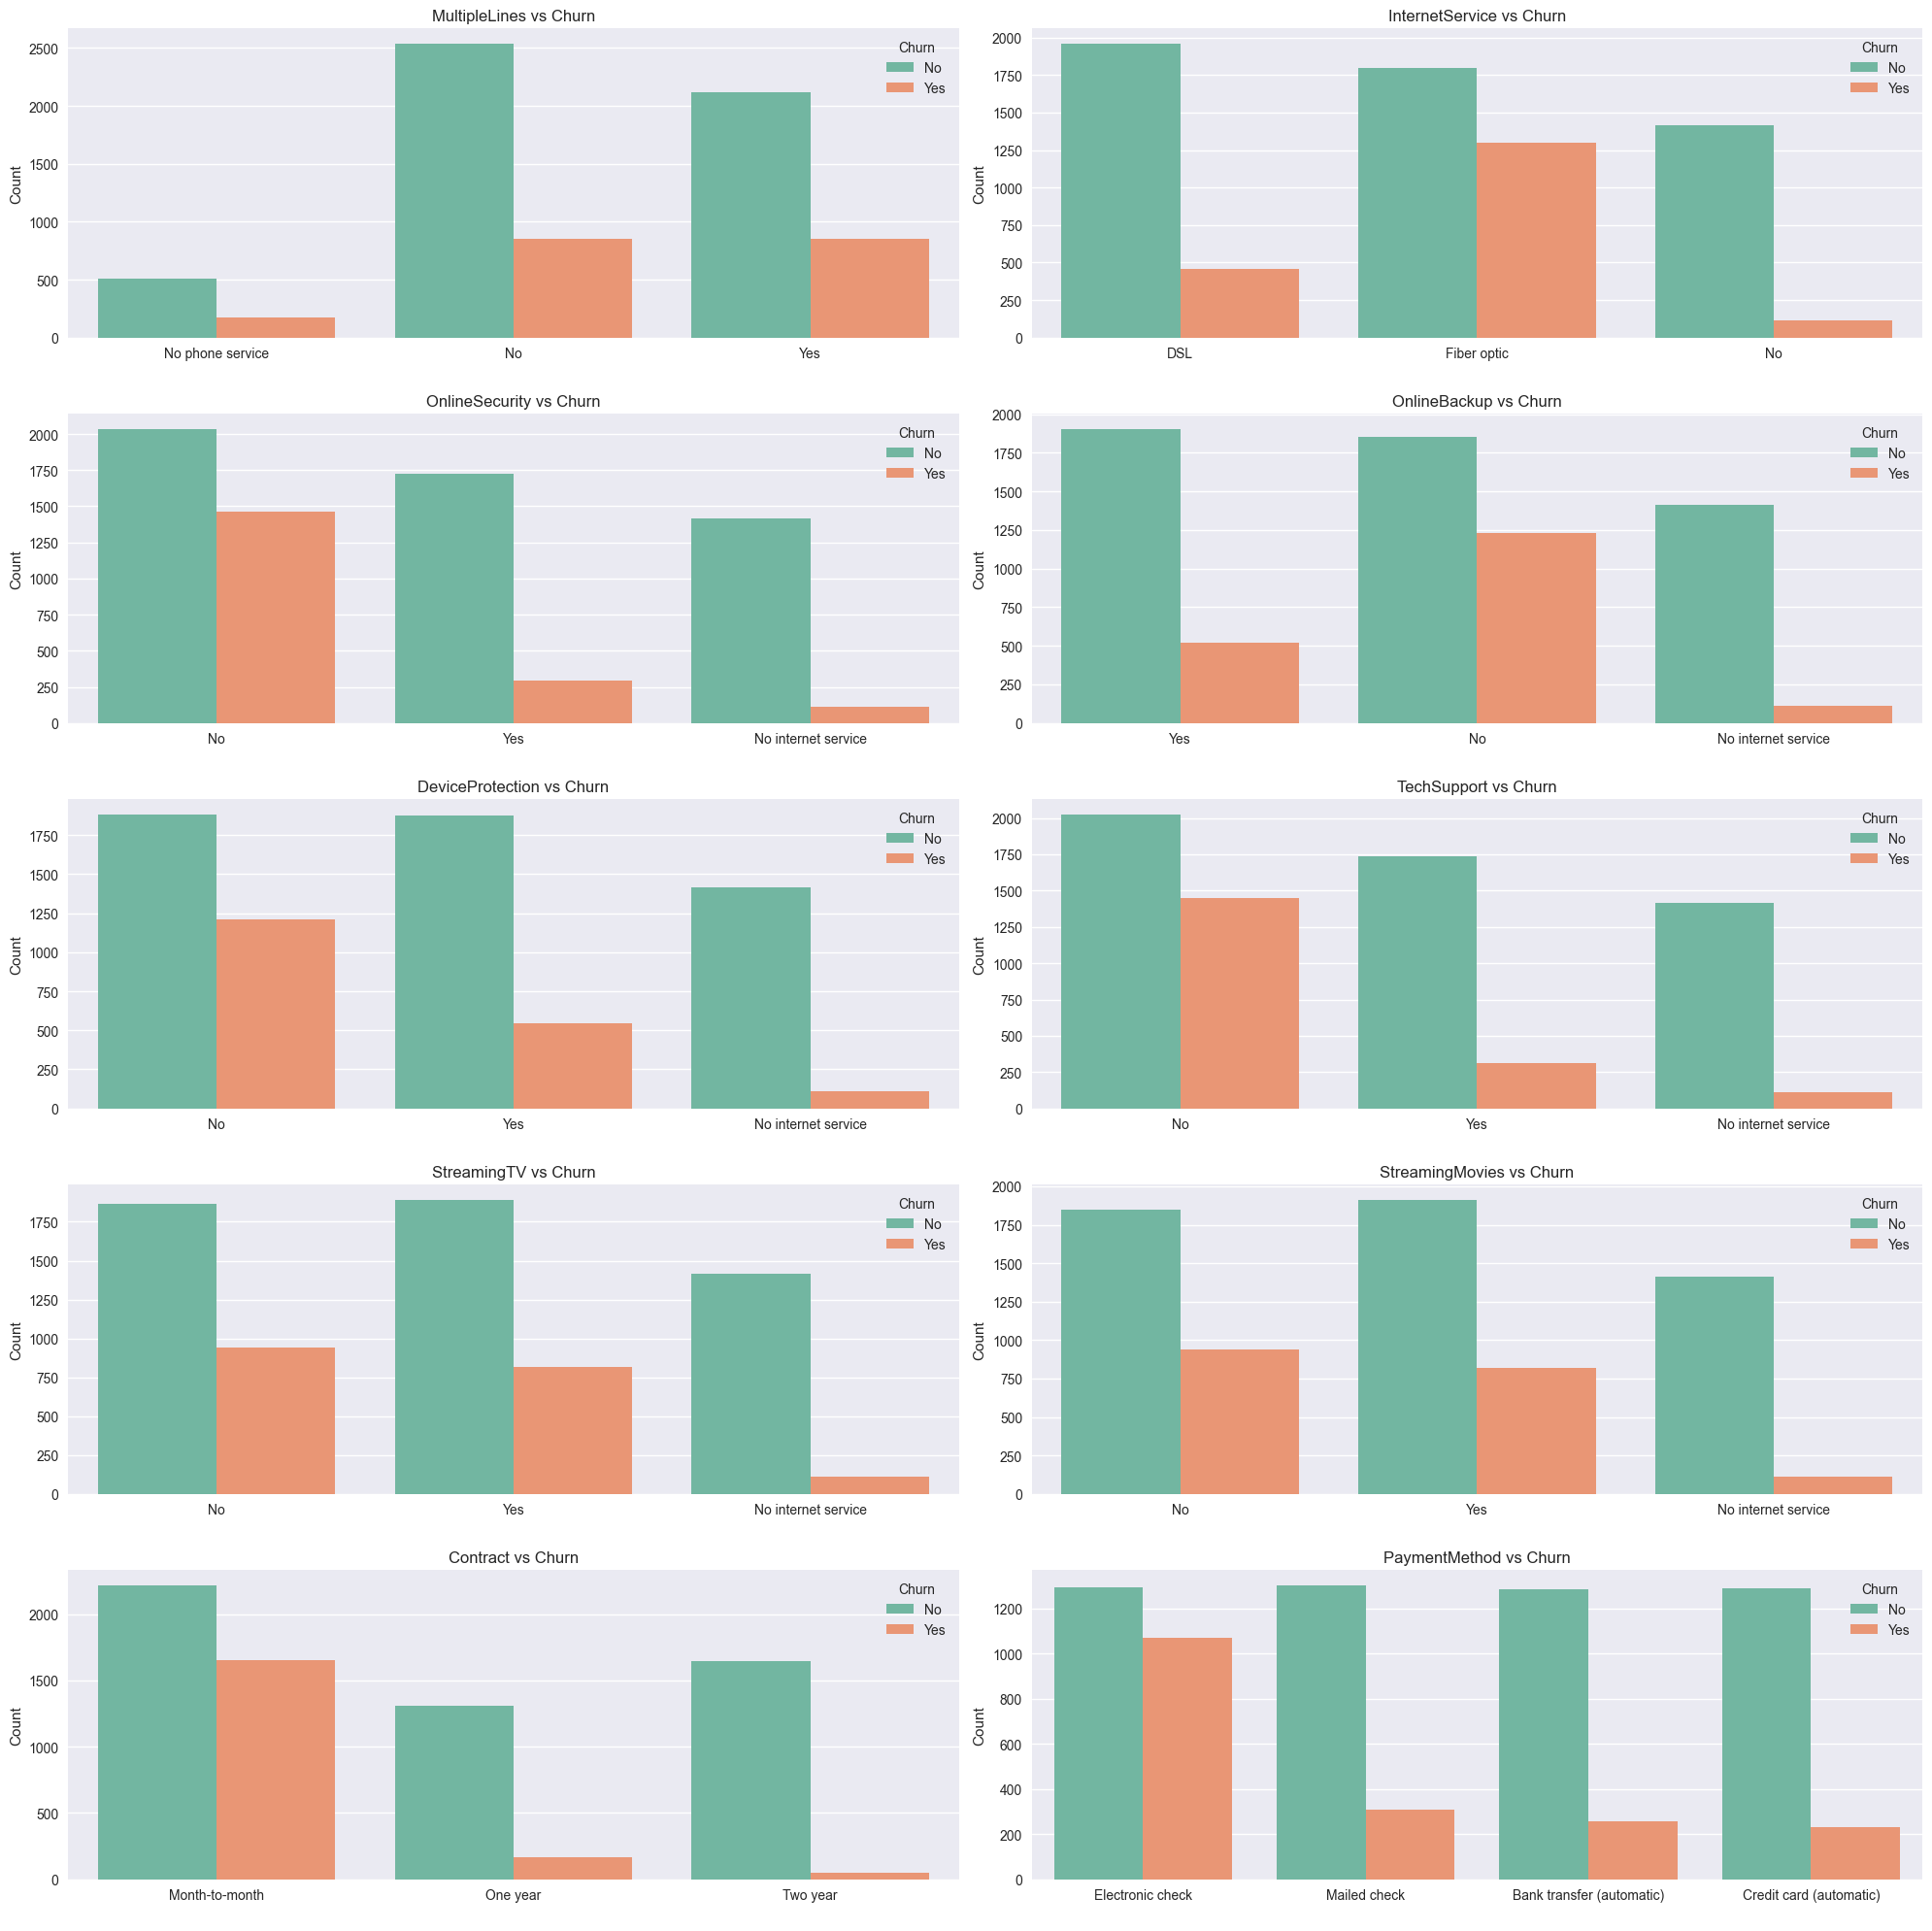


Churn Rate by Categorical Features:

MultipleLines:
3 MultipleLines
Yes                 0.286099
No                  0.250442
No phone service    0.249267
Name: Churn, dtype: float64
----------------------------------------

InternetService:
3 InternetService
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: Churn, dtype: float64
----------------------------------------

OnlineSecurity:
3 OnlineSecurity
No                     0.417667
Yes                    0.146112
No internet service    0.074050
Name: Churn, dtype: float64
----------------------------------------

OnlineBackup:
3 OnlineBackup
No                     0.399288
Yes                    0.215315
No internet service    0.074050
Name: Churn, dtype: float64
----------------------------------------

DeviceProtection:
3 DeviceProtection
No                     0.391276
Yes                    0.225021
No internet service    0.074050
Name: Churn, dtype: float64
----------------------------------------



In [23]:
# Visualization for Categorical Features
plt.figure(figsize=(20,20))

for i, feature in enumerate(categorical_features, 1):
    plt.subplot(5,2,i)
    sns.countplot(data = df, x = feature, hue = "Churn", palette = "Set2")
    plt.title(f"{feature} vs Churn", fontsize = 12)
    plt.xlabel(" ")
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("Churn Rate by Categorical Features:")
print("="*50)
for col in categorical_features:
    churn_rate = df.groupby(col)["Churn"].apply(lambda x: (x == 'Yes').mean()).sort_values(ascending=False)
    print(f"\n{col}:")
    print(churn_rate)
    print("-" * 40)

**Insights (Categorical Features):**
- Categorical variables such as Contract type, InternetService, and add-on services (OnlineSecurity, TechSupport) show strong links to churn behavior.  
- Customers with month-to-month contracts, fiber optic internet, and no additional services are at the highest churn risk.  
- Those who pay via *electronic check* also tend to churn more frequently compared to other payment methods.

In [21]:
# Outlier detection with IQR
def detect_outliers(df, features):
    outlier_summary = {}
    for feature in features:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
        outlier_summary[feature] = {
            'count': len(outliers),
            'percentage': len(outliers) / len(df) * 100
        }
        print(f"{feature}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")
    return outlier_summary

outliers = detect_outliers(df, numeric_features)

tenure: 0 outliers (0.00%)
MonthlyCharges: 0 outliers (0.00%)
TotalCharges: 0 outliers (0.00%)


* No significal outliers were detected in numerical variables using IQR method.
* The data distribution appears consistent and within expected bussiness ranges

## Overall EDA Summary

- The overall **churn rate** is approximately 26–27%, which is typical for telecom companies.  
- **Tenure** and **Contract type** are the most influential features — customers early in their lifecycle and on month-to-month contracts are more likely to leave.  
- **High MonthlyCharges** are also linked to higher churn, suggesting cost sensitivity among premium users.  
- **Senior citizens**, **single customers**, and **those using paperless billing** show higher churn risk.  
- Customers with **add-on services** (like *OnlineSecurity* or *TechSupport*) tend to stay longer, implying these features increase loyalty.  

 **Implications:**  
Improving retention for short-tenure and high-cost customers could significantly reduce churn.  
Offering bundled services or loyalty incentives may help maintain long-term subscribers.
